# **k-means**

Saving data-1.xlsx to data-1 (6).xlsx
จำนวนข้อมูล: 1199


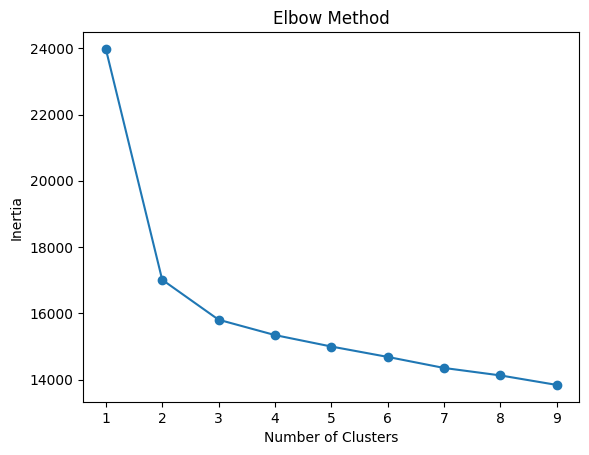

Cluster Size
Cluster
0    534
2    349
1    316
Name: count, dtype: int64

Cluster Mean
         Variable X  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
Cluster                                                               
0          4.681648    4.537453    4.541199    4.310861    4.492509   
1          3.056962    2.908228    2.962025    2.990506    3.047468   
2          4.229226    3.819484    3.939828    3.429799    3.719198   

         Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  \
Cluster                                                                
0          4.471910    4.490637    4.385768    4.657303     4.576779   
1          3.221519    3.003165    2.873418    2.933544     3.044304   
2          3.595989    3.977077    3.441261    4.048711     3.982808   

         Unnamed: 11  Unnamed: 12  Unnamed: 13  Unnamed: 14  Unnamed: 15  \
Cluster                                                                    
0           4.659176     4.795880     4.726

In [67]:
# ===== IMPORT LIBRARIES =====
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import files

# ===== UPLOAD FILE =====
uploaded = files.upload()

# ===== READ DATA =====
df = pd.read_excel(list(uploaded.keys())[0])

# ===== CLEAN DATA =====
df = df.iloc[3:]   # ลบ 3 แถวแรก
df = df.reset_index(drop=True)

df = df.drop(columns=["คนที่"], errors="ignore")

df = df.apply(pd.to_numeric, errors='coerce')

print("จำนวนข้อมูล:", len(df))   # ควรได้ 1200

# ===== STANDARDIZE =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ===== ELBOW METHOD =====
inertia = []
K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# ===== KMEANS =====
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster Size")
print(df["Cluster"].value_counts())

print("\nCluster Mean")
print(df.groupby("Cluster").mean())


# **one-way anova**

In [68]:
from scipy.stats import f_oneway
import pandas as pd

anova_results = {}

for col in df.columns[:-1]:

    group0 = df[df["Cluster"]==0][col]
    group1 = df[df["Cluster"]==1][col]
    group2 = df[df["Cluster"]==2][col]

    f_stat, p_value = f_oneway(group0, group1, group2)

    anova_results[col] = p_value

anova_table = pd.DataFrame.from_dict(anova_results, orient='index', columns=['p-value'])

print("ANOVA Result")
print(anova_table)

print("\nVariables with Significant Difference (p < 0.05)")
print(anova_table[anova_table["p-value"] < 0.05])


ANOVA Result
                   p-value
Variable X   7.950059e-123
Unnamed: 2   8.577684e-117
Unnamed: 3   2.090908e-115
Unnamed: 4    8.767374e-81
Unnamed: 5    1.575402e-95
Unnamed: 6    1.184254e-77
Unnamed: 7    6.203103e-94
Unnamed: 8    9.008210e-83
Unnamed: 9   6.135980e-123
Unnamed: 10  2.637457e-104
Unnamed: 11  3.992592e-145
Unnamed: 12  8.186491e-149
Unnamed: 13  2.231299e-137
Unnamed: 14  2.448423e-133
Unnamed: 15  1.043031e-148
Unnamed: 16  1.731713e-107
Unnamed: 17  4.551327e-110
Variable Y    1.106021e-87
Unnamed: 19  4.579051e-108
Unnamed: 20   8.642667e-63

Variables with Significant Difference (p < 0.05)
                   p-value
Variable X   7.950059e-123
Unnamed: 2   8.577684e-117
Unnamed: 3   2.090908e-115
Unnamed: 4    8.767374e-81
Unnamed: 5    1.575402e-95
Unnamed: 6    1.184254e-77
Unnamed: 7    6.203103e-94
Unnamed: 8    9.008210e-83
Unnamed: 9   6.135980e-123
Unnamed: 10  2.637457e-104
Unnamed: 11  3.992592e-145
Unnamed: 12  8.186491e-149
Unnamed: 13  2.2312

# **random forest**

# Group 1



In [14]:
from google.colab import files
uploaded = files.upload()

Saving G1-rdf.csv to G1-rdf.csv


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# โหลดข้อมูล
df = pd.read_csv("G1-rdf.csv", header=None)

data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# กลุ่มตัวแปร
groups = {
"product": product,
"price": price,
"place": place,
"promotion": promotion
}

# สร้างโฟลเดอร์เก็บกราฟ
os.makedirs("importance_graphs", exist_ok=True)

count = 1

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Question": [f"Question {i+1}" for i in range(len(X.columns))],
            "Importance": importance
        })

        # เรียงลำดับ
        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        plt.figure(figsize=(7,4))

        bars = plt.barh(
            importance_df["Question"],
            importance_df["Importance"]
        )

        # ใส่ตัวเลข importance ปลายกราฟ
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f"{width:.3f}",
                     va='center')

        plt.title(f"Group 1{gname} with Variable Y{i+1}", fontsize=12)

        plt.xlabel("Feature Importance")
        plt.ylabel(f"{gname}")

        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.tight_layout()

        plt.savefig(f"importance_graphs/graph_{count}.png", dpi=300)

        plt.close()

        count += 1

In [16]:
import shutil
from google.colab import files

shutil.make_archive("feature_importance_graphs",'zip',"importance_graphs")

files.download("feature_importance_graphs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 2

In [17]:
from google.colab import files
uploaded = files.upload()

Saving G2-rfd.csv to G2-rfd.csv


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# โหลดไฟล์
df = pd.read_csv("G2-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# กลุ่มตัวแปร
groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

# สร้างโฟลเดอร์
os.makedirs("importance_graphs_G2", exist_ok=True)

count = 1

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Question": [f"Question {i+1}" for i in range(len(X.columns))],
            "Importance": importance
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        plt.figure(figsize=(7,4))

        bars = plt.barh(
            importance_df["Question"],
            importance_df["Importance"]
        )

        # ใส่ตัวเลข importance
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f"{width:.3f}",
                     va='center')

        plt.title(f"Group 2: {gname} vs Variable Y{i+1}", fontsize=12)

        plt.xlabel("Feature Importance")
        plt.ylabel(f"{gname}")

        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.tight_layout()

        plt.savefig(f"importance_graphs_G2/graph_{count}.png", dpi=300)

        plt.close()

        count += 1

In [21]:
import shutil
from google.colab import files

shutil.make_archive("feature_importance_graphs_G2",'zip',"importance_graphs_G2")

files.download("feature_importance_graphs_G2.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 3

In [22]:
from google.colab import files
uploaded = files.upload()


Saving G3-rfd.csv to G3-rfd.csv


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# โหลดไฟล์
df = pd.read_csv("G3-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

# กลุ่มตัวแปร
groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

# สร้างโฟลเดอร์
os.makedirs("importance_graphs_G3", exist_ok=True)

count = 1

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Question": [f"Question {i+1}" for i in range(len(X.columns))],
            "Importance": importance
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=True
        )

        plt.figure(figsize=(7,4))

        bars = plt.barh(
            importance_df["Question"],
            importance_df["Importance"]
        )

        # ใส่ตัวเลข importance ปลายแท่ง
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001,
                     bar.get_y() + bar.get_height()/2,
                     f"{width:.3f}",
                     va='center')

        plt.title(f"Group 3: {gname} vs Variable Y{i+1}", fontsize=12)

        plt.xlabel("Feature Importance")
        plt.ylabel(f"{gname}")

        plt.grid(axis='x', linestyle='--', alpha=0.6)

        plt.tight_layout()

        plt.savefig(f"importance_graphs_G3/graph_{count}.png", dpi=300)

        plt.close()

        count += 1

In [25]:
import shutil
from google.colab import files

shutil.make_archive("feature_importance_graphs_G3",'zip',"importance_graphs_G3")

files.download("feature_importance_graphs_G3.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Accuracy/F1**

# Group 1

In [26]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# โหลดไฟล์ Group 1
df = pd.read_csv("G1-rdf.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

groups = {
    "Product": product,
    "Price": price,
    "Place": place,
    "Promotion": promotion
}

results = []

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": f"{gname} - Y{i+1}",
            "Accuracy": round(accuracy,3),
            "Precision": round(precision,3),
            "Recall": round(recall,3),
            "F1-score": round(f1,3)
        })

results_df = pd.DataFrame(results)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

             Model  Accuracy  Precision  Recall  F1-score
0     Product - Y1     0.575      0.569   0.575     0.558
1     Product - Y2     0.550      0.537   0.550     0.542
2     Product - Y3     0.406      0.386   0.406     0.394
3       Price - Y1     0.556      0.558   0.556     0.543
4       Price - Y2     0.594      0.579   0.594     0.586
5       Price - Y3     0.487      0.465   0.487     0.474
6       Place - Y1     0.500      0.508   0.500     0.427
7       Place - Y2     0.537      0.501   0.537     0.487
8       Place - Y3     0.456      0.334   0.456     0.378
9   Promotion - Y1     0.600      0.566   0.600     0.581
10  Promotion - Y2     0.537      0.517   0.537     0.526
11  Promotion - Y3     0.512      0.504   0.512     0.463


In [27]:
results_df.to_excel("Group1_Model_Performance.xlsx", index=False)

In [28]:
from google.colab import files
files.download("Group1_Model_Performance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 2

In [29]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# โหลดไฟล์ Group 2
df = pd.read_csv("G2-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

results = []

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": f"{gname} - Y{i+1}",
            "Accuracy": round(accuracy,3),
            "Precision": round(precision,3),
            "Recall": round(recall,3),
            "F1-score": round(f1,3)
        })

results_df = pd.DataFrame(results)

print(results_df)

             Model  Accuracy  Precision  Recall  F1-score
0     Product - Y1     0.229      0.253   0.229     0.229
1     Product - Y2     0.188      0.181   0.188     0.174
2     Product - Y3     0.271      0.266   0.271     0.265
3       Price - Y1     0.229      0.311   0.229     0.250
4       Price - Y2     0.198      0.226   0.198     0.191
5       Price - Y3     0.271      0.270   0.271     0.270
6       Place - Y1     0.250      0.236   0.250     0.240
7       Place - Y2     0.292      0.289   0.292     0.281
8       Place - Y3     0.219      0.212   0.219     0.214
9   Promotion - Y1     0.271      0.276   0.271     0.271
10  Promotion - Y2     0.271      0.246   0.271     0.254
11  Promotion - Y3     0.188      0.224   0.188     0.198


In [30]:
results_df.to_excel("Group2_Model_Performance.xlsx", index=False)

In [31]:
from google.colab import files
files.download("Group2_Model_Performance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 3

In [32]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# โหลดไฟล์
df = pd.read_csv("G3-rfd.csv", header=None)

# ลบ 3 แถวแรก
data = df.iloc[3:].reset_index(drop=True)
data = data.astype(float)

# แยกตัวแปร
product = data.iloc[:,0:5]
price = data.iloc[:,5:11]
place = data.iloc[:,11:14]
promotion = data.iloc[:,14:17]

Y = data.iloc[:,17:20]

groups = {
"Product": product,
"Price": price,
"Place": place,
"Promotion": promotion
}

results = []

for gname, X in groups.items():

    for i, ycol in enumerate(Y.columns):

        y = Y[ycol]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        model = RandomForestClassifier(random_state=42)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Model": f"{gname} - Y{i+1}",
            "Accuracy": round(accuracy,3),
            "Precision": round(precision,3),
            "Recall": round(recall,3),
            "F1-score": round(f1,3)
        })

results_df = pd.DataFrame(results)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

             Model  Accuracy  Precision  Recall  F1-score
0     Product - Y1     0.340      0.261   0.340     0.291
1     Product - Y2     0.519      0.464   0.519     0.450
2     Product - Y3     0.396      0.394   0.396     0.374
3       Price - Y1     0.462      0.421   0.462     0.428
4       Price - Y2     0.491      0.426   0.491     0.439
5       Price - Y3     0.425      0.406   0.425     0.400
6       Place - Y1     0.387      0.346   0.387     0.335
7       Place - Y2     0.434      0.399   0.434     0.414
8       Place - Y3     0.368      0.544   0.368     0.348
9   Promotion - Y1     0.377      0.306   0.377     0.318
10  Promotion - Y2     0.500      0.477   0.500     0.449
11  Promotion - Y3     0.453      0.504   0.453     0.425


In [33]:
results_df.to_excel("Group3_Model_Performance.xlsx", index=False)

In [34]:
from google.colab import files
files.download("Group3_Model_Performance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **ordinal logistic regression**

# Group 1

In [51]:
from google.colab import files
uploaded = files.upload()

Saving G1-olr.csv to G1-olr (1).csv


In [53]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดไฟล์ และลบ 3 แถวแรก
df = pd.read_csv('/content/G1-olr.csv', header=None)
df = df.iloc[3:].reset_index(drop=True)

# ตั้งชื่อคอลัมน์ใหม่
df.columns = [f"Q{i}" for i in range(1,18)] + ["Y1","Y2","Y3"]

# แปลงเป็นตัวเลข
df = df.astype(float)

# สร้างตัวแปร X (ค่าเฉลี่ยแต่ละหมวด)

df['Product'] = df[['Q1','Q2','Q3','Q4','Q5']].mean(axis=1)

df['Price'] = df[['Q6','Q7','Q8','Q9','Q10','Q11']].mean(axis=1)

df['Place'] = df[['Q12','Q13','Q14']].mean(axis=1)

df['Promotion'] = df[['Q15','Q16','Q17']].mean(axis=1)

X = df[['Product','Price','Place','Promotion']]


# ฟังก์ชันรัน Ordinal Logistic
def run_model(y_var):

    y = df[y_var]

    model = OrderedModel(y, X, distr='logit')
    result = model.fit(method='bfgs', disp=False)

    params = result.params
    se = result.bse
    p = result.pvalues

    OR = np.exp(params)

    conf = result.conf_int()
    CI_low = np.exp(conf[0])
    CI_high = np.exp(conf[1])

    table = pd.DataFrame({
        "Variable": params.index,
        "Coefficient": params.values,
        "SE": se.values,
        "Odds Ratio": OR.values,
        "CI Lower": CI_low.values,
        "CI Upper": CI_high.values,
        "p-value": p.values
    })

    # เอา threshold ออก
    table = table[~table["Variable"].str.contains("/")]

    return table


# รันโมเดล
Y1 = run_model("Y1")
Y2 = run_model("Y2")
Y3 = run_model("Y3")


# export Excel
with pd.ExcelWriter("Ordinal_Logistic_G1.xlsx") as writer:

    Y1.to_excel(writer, sheet_name="Y1", index=False)
    Y2.to_excel(writer, sheet_name="Y2", index=False)
    Y3.to_excel(writer, sheet_name="Y3", index=False)

print("เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย")

เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย


In [54]:
from google.colab import files
files.download("Ordinal_Logistic_G1.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 2

In [55]:
from google.colab import files
uploaded = files.upload()

Saving G2-olr.csv to G2-olr (1).csv


In [56]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดไฟล์ และลบ 3 แถวแรก
df = pd.read_csv('/content/G2-olr.csv', header=None)
df = df.iloc[3:].reset_index(drop=True)

# ตั้งชื่อคอลัมน์ใหม่
df.columns = [f"Q{i}" for i in range(1,18)] + ["Y1","Y2","Y3"]

# แปลงเป็นตัวเลข
df = df.astype(float)

# สร้างตัวแปร X (ค่าเฉลี่ยแต่ละหมวด)

df['Product'] = df[['Q1','Q2','Q3','Q4','Q5']].mean(axis=1)

df['Price'] = df[['Q6','Q7','Q8','Q9','Q10','Q11']].mean(axis=1)

df['Place'] = df[['Q12','Q13','Q14']].mean(axis=1)

df['Promotion'] = df[['Q15','Q16','Q17']].mean(axis=1)

X = df[['Product','Price','Place','Promotion']]


# ฟังก์ชันรัน Ordinal Logistic
def run_model(y_var):

    y = df[y_var]

    model = OrderedModel(y, X, distr='logit')
    result = model.fit(method='bfgs', disp=False)

    params = result.params
    se = result.bse
    p = result.pvalues

    OR = np.exp(params)

    conf = result.conf_int()
    CI_low = np.exp(conf[0])
    CI_high = np.exp(conf[1])

    table = pd.DataFrame({
        "Variable": params.index,
        "Coefficient": params.values,
        "SE": se.values,
        "Odds Ratio": OR.values,
        "CI Lower": CI_low.values,
        "CI Upper": CI_high.values,
        "p-value": p.values
    })

    # เอา threshold ออก
    table = table[~table["Variable"].str.contains("/")]

    return table


# รันโมเดล
Y1 = run_model("Y1")
Y2 = run_model("Y2")
Y3 = run_model("Y3")


# export Excel
with pd.ExcelWriter("Ordinal_Logistic_G2.xlsx") as writer:

    Y1.to_excel(writer, sheet_name="Y1", index=False)
    Y2.to_excel(writer, sheet_name="Y2", index=False)
    Y3.to_excel(writer, sheet_name="Y3", index=False)

print("เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย")

เสร็จแล้ว ดาวน์โหลดไฟล์ Excel ได้เลย


In [57]:
from google.colab import files
files.download("Ordinal_Logistic_G2.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Group 3

In [58]:
from google.colab import files
uploaded = files.upload()

Saving G3-olr.csv to G3-olr (1).csv


In [59]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# โหลดไฟล์ และลบ 3 แถวแรก
df = pd.read_csv('/content/G3-olr.csv', header=None)
df = df.iloc[3:].reset_index(drop=True)

# ตั้งชื่อคอลัมน์ใหม่
df.columns = [f"Q{i}" for i in range(1,18)] + ["Y1","Y2","Y3"]

# แปลงเป็นตัวเลข
df = df.astype(float)

# สร้างตัวแปร X (ค่าเฉลี่ยแต่ละหมวด)

df['Product'] = df[['Q1','Q2','Q3','Q4','Q5']].mean(axis=1)

df['Price'] = df[['Q6','Q7','Q8','Q9','Q10','Q11']].mean(axis=1)

df['Place'] = df[['Q12','Q13','Q14']].mean(axis=1)

df['Promotion'] = df[['Q15','Q16','Q17']].mean(axis=1)

X = df[['Product','Price','Place','Promotion']]


# ฟังก์ชันรัน Ordinal Logistic
def run_model(y_var):

    y = df[y_var]

    model = OrderedModel(y, X, distr='logit')
    result = model.fit(method='bfgs', disp=False)

    params = result.params
    se = result.bse
    p = result.pvalues

    OR = np.exp(params)

    conf = result.conf_int()
    CI_low = np.exp(conf[0])
    CI_high = np.exp(conf[1])

    table = pd.DataFrame({
        "Variable": params.index,
        "Coefficient": params.values,
        "SE": se.values,
        "Odds Ratio": OR.values,
        "CI Lower": CI_low.values,
        "CI Upper": CI_high.values,
        "p-value": p.values
    })

    # เอา threshold ออก
    table = table[~table["Variable"].str.contains("/")]

    return table


# รันโมเดล
Y1 = run_model("Y1")
Y2 = run_model("Y2")
Y3 = run_model("Y3")


# export Excel
with pd.ExcelWriter("Ordinal_Logistic_G3.xlsx") as writer:

    Y1.to_excel(writer, sheet_name="Y1", index=False)
    Y2.to_excel(writer, sheet_name="Y2", index=False)
    Y3.to_excel(writer, sheet_name="Y3", index=False)



In [60]:
from google.colab import files
files.download("Ordinal_Logistic_G3.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>